In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, roc_curve, classification_report)
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE


In [2]:
PROJECT_ROOT = Path('../')
DATA_OUT     = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR  = PROJECT_ROOT / 'figures'

In [3]:
X_train = pd.read_csv(DATA_OUT / 'X_train.csv')
X_test  = pd.read_csv(DATA_OUT / 'X_test.csv')
y_train = pd.read_csv(DATA_OUT / 'y_train.csv').squeeze()
y_test  = pd.read_csv(DATA_OUT / 'y_test.csv').squeeze()

baseline_metrics = pd.read_csv(DATA_OUT / 'metrics_lr_baseline.csv')

race_map = {1: 'Mexican American', 2: 'Other Hispanic', 3: 'NH White',
            4: 'NH Black', 6: 'NH Asian', 7: 'Other/Multi'}
sex_map  = {1: 'Male', 2: 'Female'}

print(f"Train: {X_train.shape} — {y_train.mean():.1%} diabetic")
print(f"Test:  {X_test.shape}  — {y_test.mean():.1%} diabetic")

Train: (13200, 5) — 15.1% diabetic
Test:  (3301, 5)  — 15.1% diabetic


In [4]:
print("Before SMOTE")
print(f"Class distribution:\n{y_train.value_counts()}")
print(f"Total training samples: {len(y_train)}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE")
print(f"Class distribution:\n{pd.Series(y_train_sm).value_counts()}")
print(f"Total training samples: {len(y_train_sm)}")
print(f"New class balance: {y_train_sm.mean():.1%} diabetic")

Before SMOTE
Class distribution:
diabetes
0.0    11208
1.0     1992
Name: count, dtype: int64
Total training samples: 13200

After SMOTE
Class distribution:
diabetes
0.0    11208
1.0    11208
Name: count, dtype: int64
Total training samples: 22416
New class balance: 50.0% diabetic


In [5]:
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight=None  # no need for class_weight since SMOTE already balanced it
)

lr_smote.fit(X_train_sm, y_train_sm)

y_pred       = lr_smote.predict(X_test)
y_pred_proba = lr_smote.predict_proba(X_test)[:, 1]

print("Overall performance — SMOTE model")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Diabetes']))
print(f"AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

joblib.dump(lr_smote, DATA_OUT / 'lr_smote.pkl')
print("\nSaved lr_smote.pkl")

Overall performance — SMOTE model
              precision    recall  f1-score   support

 No Diabetes       0.95      0.85      0.90      2803
    Diabetes       0.47      0.75      0.58       498

    accuracy                           0.83      3301
   macro avg       0.71      0.80      0.74      3301
weighted avg       0.88      0.83      0.85      3301

AUC: 0.8971

Saved lr_smote.pkl


In [6]:
def compute_subgroup_metrics(model, X, y, group_col, group_map, group_name):
    results = []
    groups = X[group_col].map(group_map)

    for group_label in sorted(groups.unique()):
        mask  = groups == group_label
        X_grp = X[mask]
        y_grp = y[mask]

        if y_grp.sum() < 5:
            print(f"Skipping {group_label} — too few positives")
            continue

        proba = model.predict_proba(X_grp)[:, 1]
        pred  = model.predict(X_grp)

        results.append({
            'group_type': group_name,
            'group':      group_label,
            'n':          len(y_grp),
            'n_diabetic': int(y_grp.sum()),
            'prevalence': y_grp.mean(),
            'auc':        roc_auc_score(y_grp, proba),
            'f1':         f1_score(y_grp, pred, zero_division=0),
            'precision':  precision_score(y_grp, pred, zero_division=0),
            'recall':     recall_score(y_grp, pred, zero_division=0),
        })

    return pd.DataFrame(results)

race_metrics = compute_subgroup_metrics(
    lr_smote, X_test, y_test,
    group_col='RIDRETH3', group_map=race_map, group_name='race'
)

sex_metrics = compute_subgroup_metrics(
    lr_smote, X_test, y_test,
    group_col='RIAGENDR', group_map=sex_map, group_name='sex'
)

overall_proba = lr_smote.predict_proba(X_test)[:, 1]
overall_pred  = lr_smote.predict(X_test)
overall_metrics = pd.DataFrame([{
    'group_type': 'overall',
    'group':      'All',
    'n':          len(y_test),
    'n_diabetic': int(y_test.sum()),
    'prevalence': y_test.mean(),
    'auc':        roc_auc_score(y_test, overall_proba),
    'f1':         f1_score(y_test, overall_pred, zero_division=0),
    'precision':  precision_score(y_test, overall_pred, zero_division=0),
    'recall':     recall_score(y_test, overall_pred, zero_division=0),
}])

all_metrics = pd.concat([overall_metrics, race_metrics, sex_metrics], ignore_index=True)
all_metrics['model'] = 'lr_smote'
all_metrics = all_metrics.round(4)

print(all_metrics.to_string(index=False))

group_type            group    n  n_diabetic  prevalence    auc     f1  precision  recall    model
   overall              All 3301         498      0.1509 0.8971 0.5761     0.4680  0.7490 lr_smote
      race Mexican American  311          54      0.1736 0.8747 0.6446     0.5821  0.7222 lr_smote
      race         NH Asian  291          40      0.1375 0.8772 0.5047     0.4030  0.6750 lr_smote
      race         NH Black  669         120      0.1794 0.8826 0.5485     0.4581  0.6833 lr_smote
      race         NH White 1513         201      0.1328 0.9141 0.5740     0.4504  0.7910 lr_smote
      race   Other Hispanic  332          51      0.1536 0.9130 0.6119     0.4940  0.8039 lr_smote
      race      Other/Multi  185          32      0.1730 0.8923 0.6250     0.5208  0.7812 lr_smote
       sex           Female 1776         253      0.1425 0.8960 0.5808     0.4944  0.7036 lr_smote
       sex             Male 1525         245      0.1607 0.8986 0.5718     0.4462  0.7959 lr_smote


In [7]:
all_metrics.to_csv(DATA_OUT / 'metrics_lr_smote.csv', index=False)

master = pd.read_csv(DATA_OUT / 'all_model_metrics.csv')
master = pd.concat([master, all_metrics], ignore_index=True)
master.to_csv(DATA_OUT / 'all_model_metrics.csv', index=False)
print("Updated all_model_metrics.csv")

Updated all_model_metrics.csv


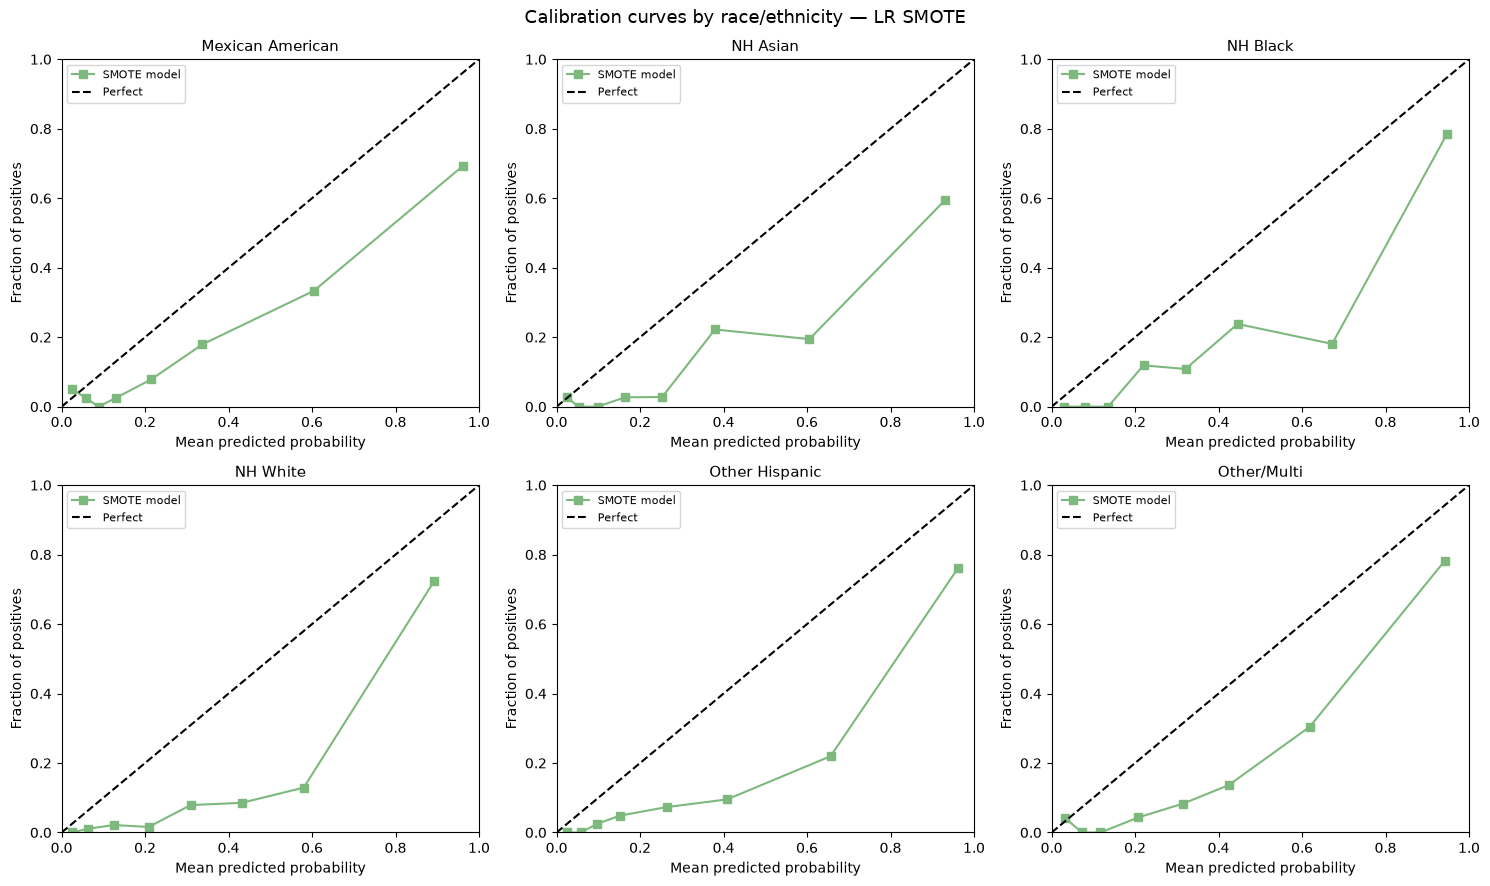

In [8]:
groups = X_test['RIDRETH3'].map(race_map)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, group_label in enumerate(sorted(groups.unique())):
    mask  = groups == group_label
    proba = lr_smote.predict_proba(X_test[mask])[:, 1]
    y_grp = y_test[mask]

    fraction_pos, mean_pred = calibration_curve(y_grp, proba, n_bins=8, strategy='quantile')

    axes[i].plot(mean_pred, fraction_pos, 's-', color='#7DB87D', label='SMOTE model')
    axes[i].plot([0, 1], [0, 1], 'k--', label='Perfect')
    axes[i].set_title(group_label, fontsize=11)
    axes[i].set_xlabel('Mean predicted probability')
    axes[i].set_ylabel('Fraction of positives')
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Calibration curves by race/ethnicity — LR SMOTE', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_calibration_by_race_lr_smote.png', dpi=150)
plt.show()

Background dataset has 13200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=13200 when initializing the masker.


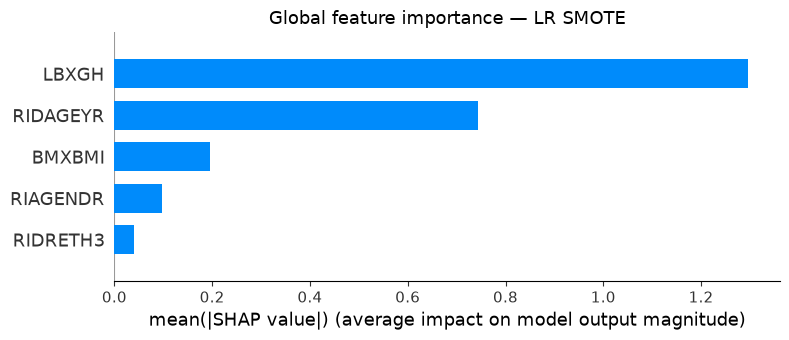

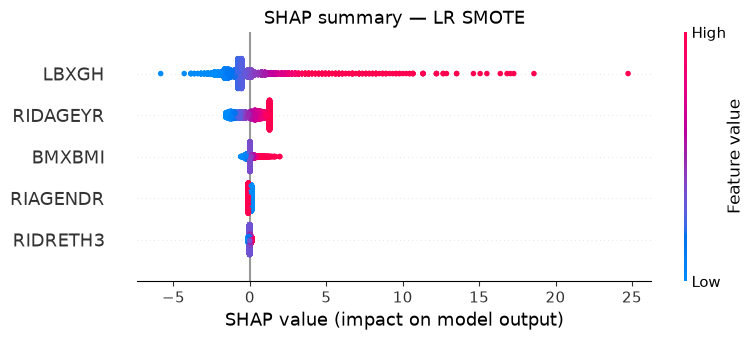

In [9]:
# Use X_train (original, not SMOTE) as background for the explainer
explainer_smote   = shap.LinearExplainer(lr_smote, X_train)
shap_values_smote = explainer_smote.shap_values(X_test)

feature_names = X_test.columns.tolist()

# Global bar chart
fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(shap_values_smote, X_test, feature_names=feature_names,
                  plot_type='bar', show=False)
plt.title('Global feature importance — LR SMOTE', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_shap_global_lr_smote.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm
fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(shap_values_smote, X_test, feature_names=feature_names, show=False)
plt.title('SHAP summary — LR SMOTE', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_shap_summary_lr_smote.png', dpi=150, bbox_inches='tight')
plt.show()

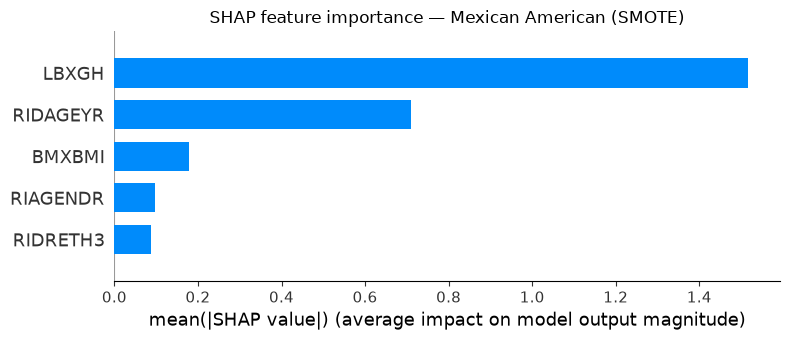

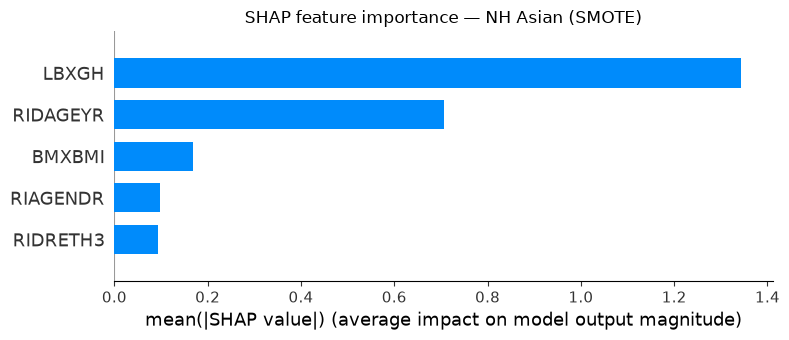

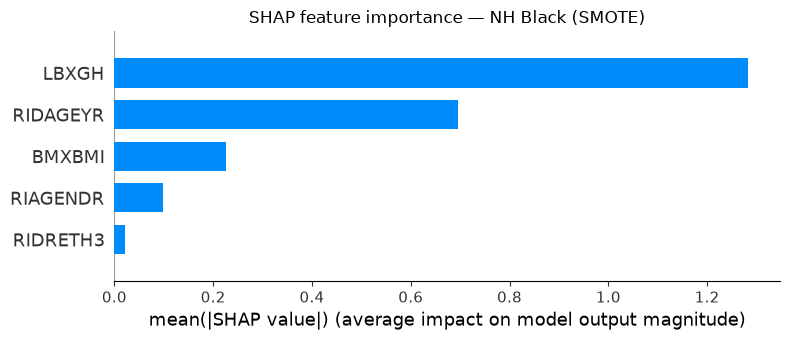

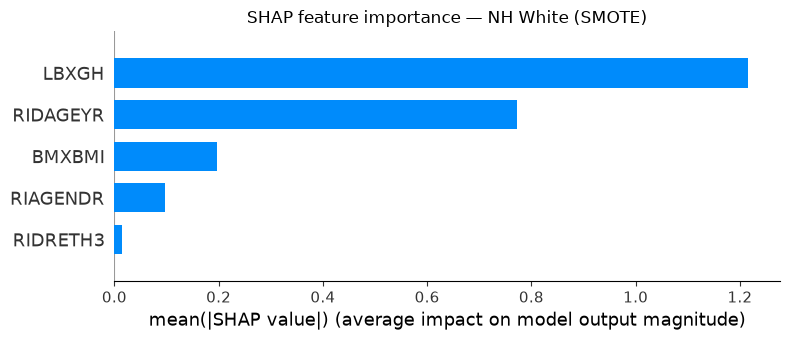

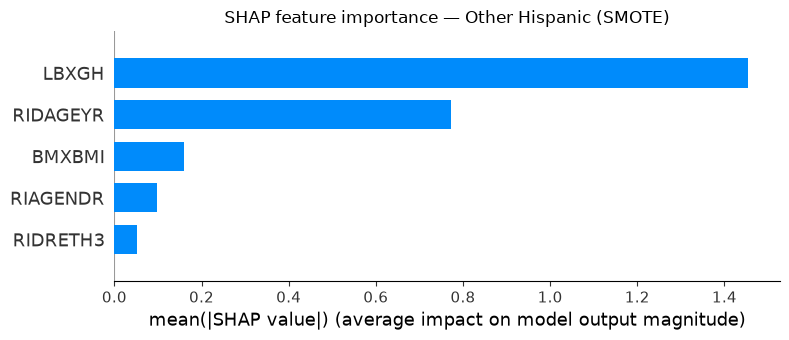

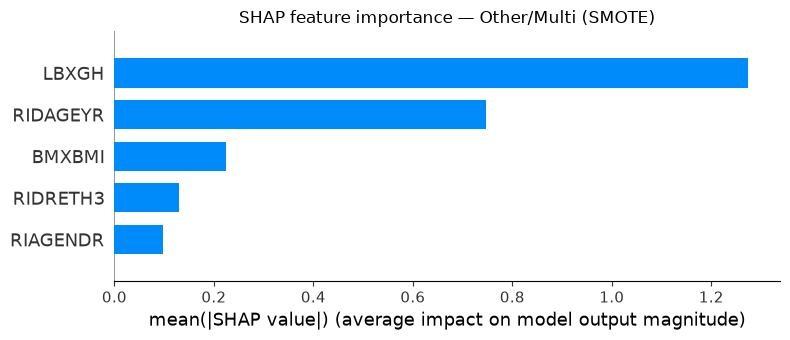

In [10]:
for group_label in sorted(groups.unique()):
    mask     = (groups == group_label).values
    shap_grp = shap_values_smote[mask]
    X_grp    = X_test[mask]

    fig, ax = plt.subplots(figsize=(8, 4))
    shap.summary_plot(shap_grp, X_grp, feature_names=feature_names,
                      plot_type='bar', show=False)
    plt.title(f'SHAP feature importance — {group_label} (SMOTE)', fontsize=12)
    plt.tight_layout()

    fname = group_label.replace('/', '_').replace(' ', '_')
    plt.savefig(FIGURES_DIR / f'fig_shap_{fname}_lr_smote.png', dpi=150, bbox_inches='tight')
    plt.show()

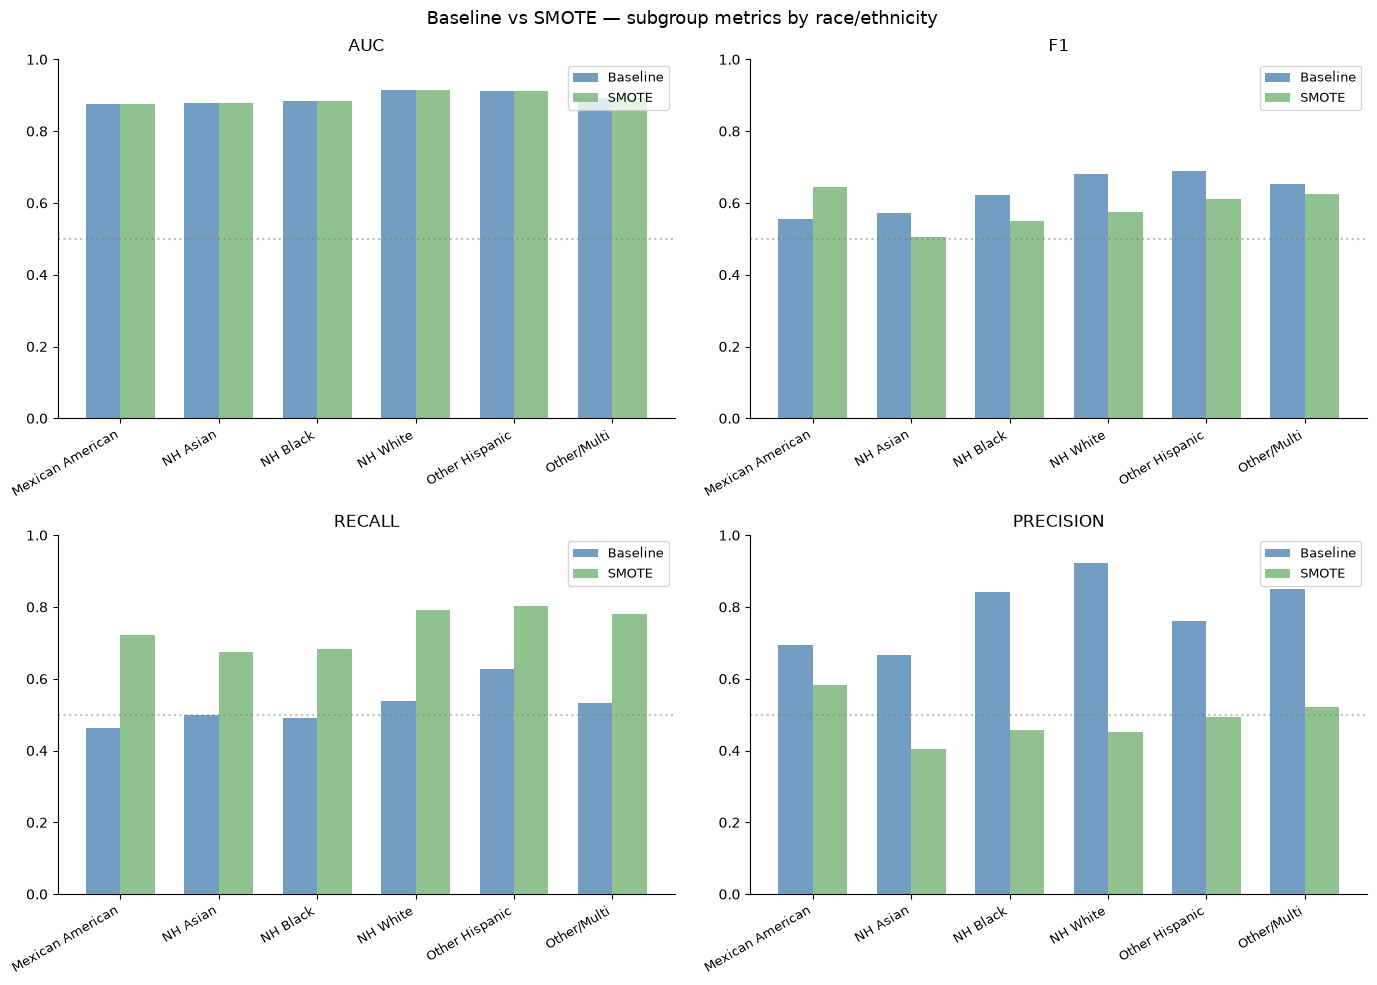

In [11]:
# Load both metric sets
baseline = pd.read_csv(DATA_OUT / 'metrics_lr_baseline.csv')
smote    = pd.read_csv(DATA_OUT / 'metrics_lr_smote.csv')

# Focus on race subgroups only
baseline_race = baseline[baseline['group_type'] == 'race'].copy()
smote_race    = smote[smote['group_type'] == 'race'].copy()

metrics_to_plot = ['auc', 'f1', 'recall', 'precision']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x = np.arange(len(baseline_race))
width = 0.35

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    bars1 = ax.bar(x - width/2, baseline_race[metric].values,
                   width, label='Baseline', color='#5B8DB8', alpha=0.85)
    bars2 = ax.bar(x + width/2, smote_race[metric].values,
                   width, label='SMOTE', color='#7DB87D', alpha=0.85)

    ax.set_title(metric.upper(), fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(baseline_race['group'].values, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
    sns.despine(ax=ax)

plt.suptitle('Baseline vs SMOTE — subgroup metrics by race/ethnicity', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_comparison_baseline_vs_smote.png', dpi=150)
plt.show()